In [ ]:
import numpy as np
import matplotlib.pyplot as plt

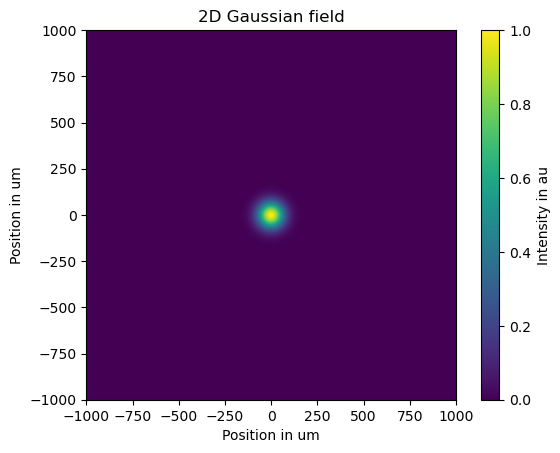

In [2]:
dx_m = 1e-6 #grid size, m:meter
Dx_m = 2e-3 #screen size
x_m = np.linspace(-Dx_m/2, Dx_m/2, int(Dx_m/dx_m)+1) #spatial grid along x-axis 

x_mean_m = 0.0 #centered on...
x_std_m = 50e-6 #widthofgaussian



dy_m = 1e-6 #grid size, m:meter
Dy_m = Dx_m
y_m = np.linspace(-Dy_m/2, Dy_m/2, int(Dy_m/dy_m)+1) #spatial grid along y-axis 



X, Y = np.meshgrid(x_m, y_m) #2D grid
uin_V_m = np.exp(-(X**2 + Y**2)/(2*(x_std_m**2))) #2D Gaussian field
plt.imshow(uin_V_m, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("2D Gaussian field")
plt.colorbar(label="Intensity in au")
plt.show()

In [3]:
def ft(t):
    return np.fft.fftshift( np.fft.fft2(np.fft.ifftshift(t)))

def ift(t):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(t)))

def fs(t):
    # works with Matlab, breaks with python
    #return (np.arange(0,1/(t[1]-t[0]),1/((t[1]-t[0])*len(t)))) - (1/(t[1]-t[0])-np.mod(len(t),2)*1/((t[1]-t[0])*len(t)))/2
    
    # from https://stackoverflow.com/questions/3694918/how-to-extract-frequency-associated-with-fft-values-in-python
    N = len(t)
    df_cpm = 1/(t[-1]-t[0])
    f_cpm = np.fft.fftshift(np.array([df_cpm*n if n<N/2 else df_cpm*(n-N) for n in range(N)]))
    return f_cpm

def propTF(E_in,L_m,lambda_m,z_m):
    #get input field array size
    (Nx, Ny)=np.shape(E_in); 
    dx=L_m/Nx; #sample interval

    #(dx<lambda.*z/L)


    fx = fs(np.arange(Nx)*dx);
    if Ny>2:
        fy = fs(np.arange(Ny)*dx);
    else:
        fy = 0;

    [FX,FY]= np.meshgrid(fx,fy);

    H=np.exp(-1j*np.pi*lambda_m*z_m*(FX**2+FY**2))

    E_out = ft(ft(E_in)*H);
    
    return E_out


In [5]:
def propTF2(uin_V_m, Lx_m, Ly_m, lambda_m, z_m):
    """
    2D transfer-function Fresnel propagation.
    uin_V_m: 2D input field (Ny, Nx)
    Lx_m, Ly_m: physical sizes of the window in x and y (meters)
    lambda_m: wavelength (meters)
    z_m: propagation distance (meters)
    """
    Ny, Nx = uin_V_m.shape
    dx = Lx_m / Nx
    dy = Ly_m / Ny

    # frequency coordinates (cycles per meter), centered
    fx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))
    fy = np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))
    FX, FY = np.meshgrid(fx, fy)

    # 2D transfer function for Fresnel propagation
    H = np.exp(-1j * np.pi * lambda_m * z_m * (FX**2 + FY**2))

    # Forward 2D FFT (shift input to center first)
    Uin = np.fft.fft2(np.fft.fftshift(uin_V_m))

    # Multiply in frequency domain and inverse FFT (then unshift)
    Uout = H * Uin
    uout = np.fft.ifftshift(np.fft.ifft2(Uout))

    return uout

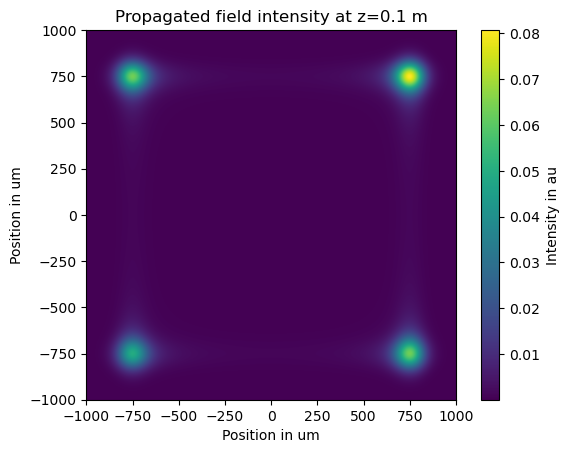

In [7]:
field = propTF2(uin_V_m, Dx_m, Dy_m, 500e-9, 0.005)
plt.imshow(np.abs(field)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6], origin='lower')
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.title("Propagated field intensity at z=0.1 m")
plt.colorbar(label="Intensity in au")
plt.show()

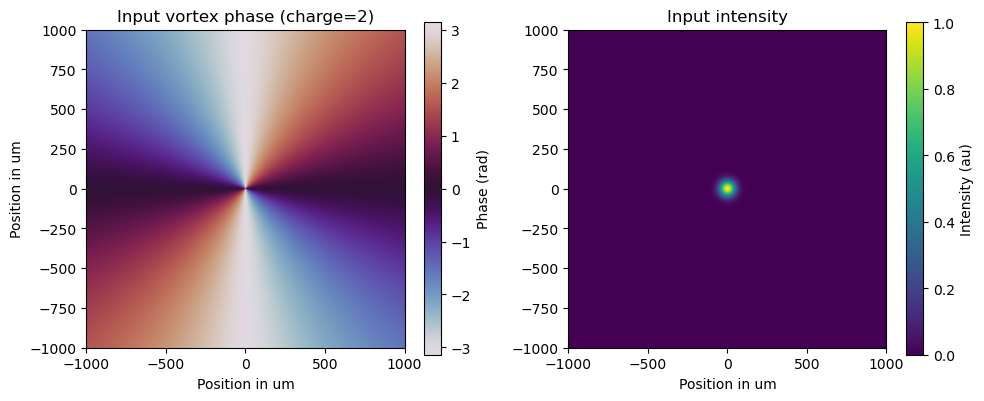

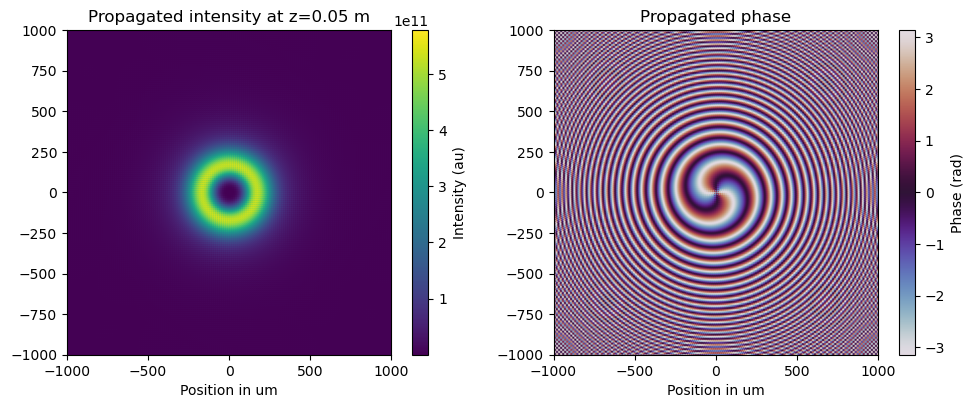

In [9]:
# generate a spiral (vortex) phase and propagate the vortex beam
charge = 2  # topological charge (try -1, 2, 3, ...)

# compute azimuthal angle
X, Y = np.meshgrid(x_m, y_m) #2D grid
theta = np.arctan2(Y, X)  #arctan is good way to get azimuthl ramp of phase  

spiral_phase = np.exp(1j * charge * theta)
vortex = uin_V_m * spiral_phase  # multiply by current amplitude (uin_V_m from earlier cell)


# copilot helped but don't fully understand ^ 


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.angle(vortex), extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower', cmap='twilight')
plt.title(f"Input vortex phase (charge={charge})")
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.colorbar(label="Phase (rad)")

plt.subplot(1,2,2)
plt.imshow(np.abs(vortex)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower')
plt.title("Input intensity")
plt.xlabel("Position in um")
plt.colorbar(label="Intensity (au)")
plt.tight_layout()
plt.show()


z_prop_m = 0.05  
wavelength = 500e-9

field_out = propTF(vortex, Dx_m, wavelength, z_prop_m)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.abs(field_out)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower')
plt.title(f"Propagated intensity at z={z_prop_m} m")
plt.xlabel("Position in um")
plt.colorbar(label="Intensity (au)")

plt.subplot(1,2,2)
plt.imshow(np.angle(field_out), extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower', cmap='twilight')
plt.title("Propagated phase")
plt.xlabel("Position in um")
plt.colorbar(label="Phase (rad)")

plt.tight_layout()
plt.show()

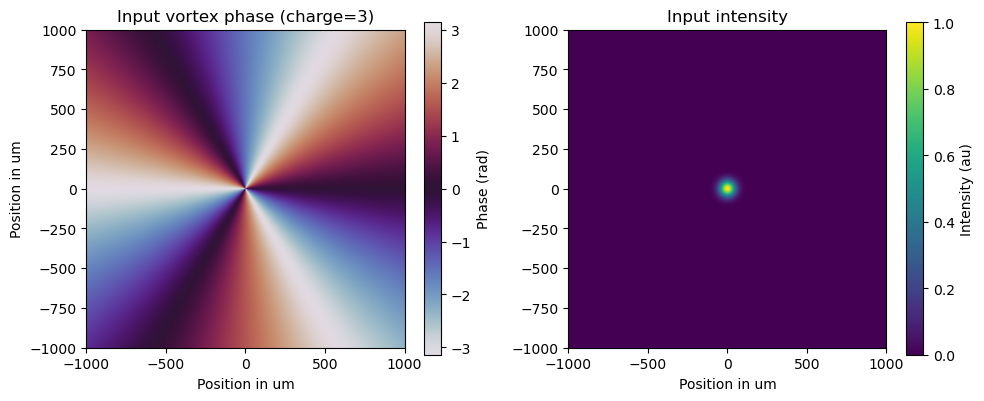

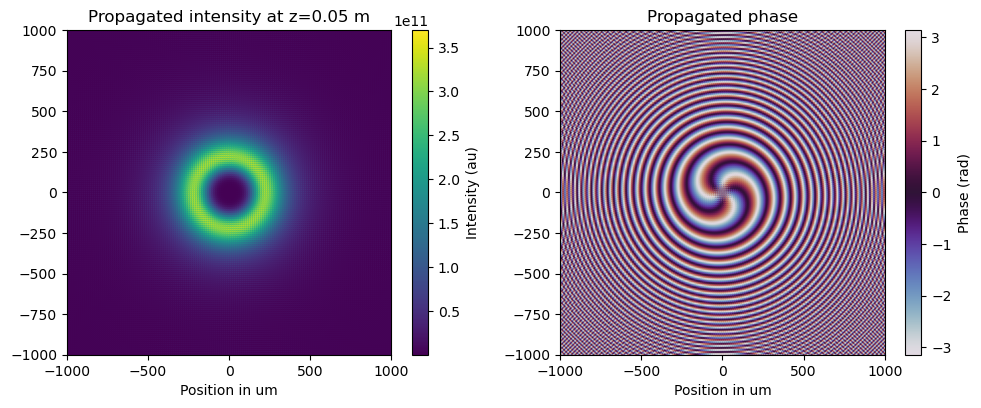

In [ ]:
# generate a spiral (vortex) phase and propagate the vortex beam
charge = 3  # topological charge (try -1, 2, 3, ...) = # "arms" of spiral

# compute azimuthal angle
X, Y = np.meshgrid(x_m, y_m) #2D grid
theta = np.arctan2(Y, X)  #arctan is good way to get azimuthl ramp of phase  

spiral_phase = np.exp(1j * charge * theta)
vortex = uin_V_m * spiral_phase  # multiply by current amplitude (uin_V_m from earlier cell)


# copilot helped but don't fully understand ^ 


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.angle(vortex), extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower', cmap='twilight')
plt.title(f"Input vortex phase (charge={charge})")
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.colorbar(label="Phase (rad)")

plt.subplot(1,2,2)
plt.imshow(np.abs(vortex)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower')
plt.title("Input intensity")
plt.xlabel("Position in um")
plt.colorbar(label="Intensity (au)")
plt.tight_layout()
plt.show()


z_prop_m = 0.05  
wavelength = 500e-9

field_out = propTF(vortex, Dx_m, wavelength, z_prop_m)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.abs(field_out)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower')
plt.title(f"Propagated intensity at z={z_prop_m} m")
plt.xlabel("Position in um")
plt.colorbar(label="Intensity (au)")

plt.subplot(1,2,2)
plt.imshow(np.angle(field_out), extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower', cmap='twilight')
plt.title("Propagated phase")
plt.xlabel("Position in um")
plt.colorbar(label="Phase (rad)")

plt.tight_layout()
plt.show()

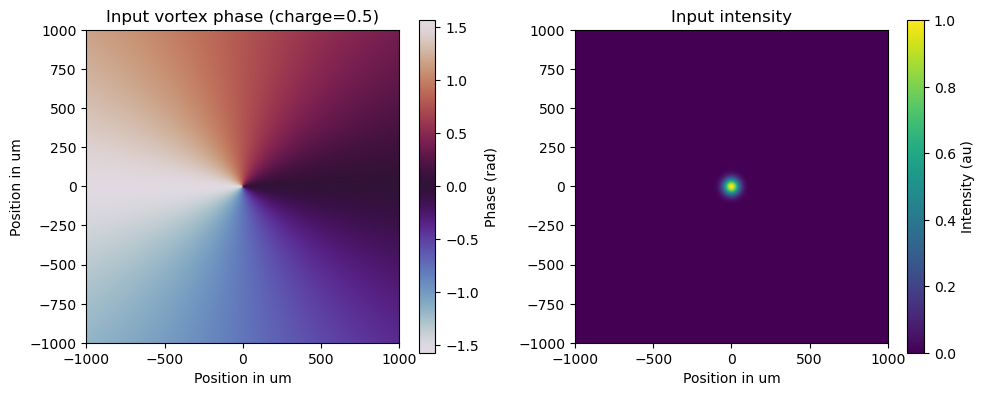

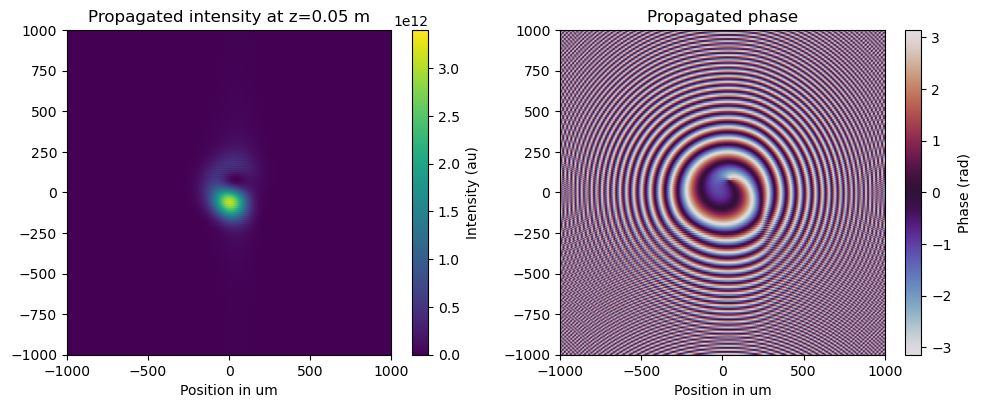

In [11]:
# generate a spiral (vortex) phase and propagate the vortex beam
charge = 0.5  # topological charge (try -1, 2, 3, ...)

# compute azimuthal angle
X, Y = np.meshgrid(x_m, y_m) #2D grid
theta = np.arctan2(Y, X)  #arctan is good way to get azimuthl ramp of phase  

spiral_phase = np.exp(1j * charge * theta)
vortex = uin_V_m * spiral_phase  # multiply by current amplitude (uin_V_m from earlier cell)


# copilot helped but don't fully understand ^ 


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.angle(vortex), extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower', cmap='twilight')
plt.title(f"Input vortex phase (charge={charge})")
plt.xlabel("Position in um")
plt.ylabel("Position in um")
plt.colorbar(label="Phase (rad)")

plt.subplot(1,2,2)
plt.imshow(np.abs(vortex)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower')
plt.title("Input intensity")
plt.xlabel("Position in um")
plt.colorbar(label="Intensity (au)")
plt.tight_layout()
plt.show()


z_prop_m = 0.05  
wavelength = 500e-9

field_out = propTF(vortex, Dx_m, wavelength, z_prop_m)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.abs(field_out)**2, extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower')
plt.title(f"Propagated intensity at z={z_prop_m} m")
plt.xlabel("Position in um")
plt.colorbar(label="Intensity (au)")

plt.subplot(1,2,2)
plt.imshow(np.angle(field_out), extent=[x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6],
           origin='lower', cmap='twilight')
plt.title("Propagated phase")
plt.xlabel("Position in um")
plt.colorbar(label="Phase (rad)")

plt.tight_layout()
plt.show()